Lina Maria Camila Lis Vanegas
Daniel Velasquez Rincon
Katerinne Garzon Sabogal


# Rodaje en tierra, combustible y CO2 (BTS 2023-2025)

**Pregunta:** ¿Qué aeropuertos y qué franjas horarias desperdician más combustible rodando en tierra con los motores encendidos, y cuánto CO2 representa eso?

**Quién lo usa:** el área de Sostenibilidad de una aerolínea o de un aeropuerto.

**Unidad de análisis:** un vuelo. Las tablas finales se agregan por aeropuerto, hora y mes.

Este cuaderno lee el Parquet completo con DuckDB. No carga los 20,9 millones de filas en memoria y no usa una muestra para los totales.

`TaxiOut` es el rodaje de salida y se atribuye al aeropuerto de origen. `TaxiIn` es el rodaje de llegada y se atribuye al de destino.


## Cómo está armado el cálculo

Los números viven en `config.py`, no escondidos en las celdas:

- escenario bajo: 6 kg de combustible por minuto;
- escenario alto: 12 kg/min, **por validar** con la base de motores OACI/EASA;
- 3,16 kg de CO2 por kg de combustible (OACI). EUROCONTROL usa 3,15; aquí no cambia ninguna conclusión.

```
combustible_kg = minutos_rodaje * consumo_kg_por_min
co2_kg         = combustible_kg * 3.16
```

El ranking de aeropuertos no depende del factor: todos se multiplican por el mismo número.


In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

raiz = Path.cwd().resolve()
if not (raiz / "config.py").exists():
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

import config

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_rows", 30)

con = duckdb.connect()
con.execute(f"""
CREATE OR REPLACE VIEW vuelos AS
SELECT *
FROM read_parquet('{config.patron_parquet()}', hive_partitioning = true)
""")
print("Parquet:", config.CARPETA_PARQUET)
print("Consumo bajo / alto (kg/min):", config.CONSUMO_KG_MIN_BAJO, config.CONSUMO_KG_MIN_ALTO)
print("Factor CO2:", config.FACTOR_CO2, "| tope de rodaje (min):", config.TAXI_MAX_MIN)


Parquet: C:\Users\linam\Documents\Proyecto\ProyectoBigData\data\parquet
Consumo bajo / alto (kg/min): 6.0 12.0
Factor CO2: 3.16 | tope de rodaje (min): 180


## 1. Tabla de verificación: esperado y obtenido

Estas cifras ya se habían medido sobre este mismo Parquet. Si una fila no cuadra, el cálculo cambió y hay que revisar la regla antes de seguir. La última fila (`grupo_hora_24_cast`) reproduce el error de la hora 24 a propósito, para demostrar que lo encontramos.


In [3]:
esperado = {
    "filas": 20_928_579,
    "taxiout_nulo": 285_189,
    "taxiin_nulo": 292_087,
    "vuelos_validos": 20_636_222,
    "horas_total": 9_057_336,
    "co2_t_bajo": 10_303_625,
    "co2_t_alto": 20_607_251,
    "grupo_hora_24_cast": 59_378,
}
tope = config.TAXI_MAX_MIN
bajo = config.CONSUMO_KG_MIN_BAJO * config.FACTOR_CO2 / 1000
alto = config.CONSUMO_KG_MIN_ALTO * config.FACTOR_CO2 / 1000
fila = con.execute(f"""
SELECT
    COUNT(*)::BIGINT AS filas,
    SUM(TaxiOut IS NULL)::BIGINT AS taxiout_nulo,
    SUM(TaxiIn IS NULL)::BIGINT AS taxiin_nulo,
    SUM(TaxiOut IS NOT NULL AND TaxiIn IS NOT NULL
        AND TaxiOut <= {tope} AND TaxiIn <= {tope})::BIGINT AS vuelos_validos,
    ROUND(SUM(CASE
        WHEN TaxiOut IS NOT NULL AND TaxiIn IS NOT NULL
         AND TaxiOut <= {tope} AND TaxiIn <= {tope}
        THEN TaxiOut + TaxiIn ELSE 0 END) / 60) AS horas_total,
    ROUND(SUM(CASE
        WHEN TaxiOut IS NOT NULL AND TaxiIn IS NOT NULL
         AND TaxiOut <= {tope} AND TaxiIn <= {tope}
        THEN (TaxiOut + TaxiIn) * {bajo} ELSE 0 END)) AS co2_t_bajo,
    ROUND(SUM(CASE
        WHEN TaxiOut IS NOT NULL AND TaxiIn IS NOT NULL
         AND TaxiOut <= {tope} AND TaxiIn <= {tope}
        THEN (TaxiOut + TaxiIn) * {alto} ELSE 0 END)) AS co2_t_alto,
    SUM(TaxiOut IS NOT NULL AND TaxiOut <= {tope} AND CRSDepTime < 2400
        AND CAST(CRSDepTime / 100 AS INTEGER) = 24)::BIGINT AS grupo_hora_24_cast
FROM vuelos
""").fetchdf().iloc[0]

verificacion = pd.DataFrame({
    "medida": list(esperado),
    "esperado": list(esperado.values()),
    "obtenido": [fila[m] for m in esperado],
})
verificacion["cuadra"] = verificacion["esperado"] == verificacion["obtenido"]
verificacion


,medida,esperado,obtenido,cuadra
0,filas,20928579,"20,928,579.00",True
1,taxiout_nulo,285189,"285,189.00",True
2,taxiin_nulo,292087,"292,087.00",True
3,vuelos_validos,20636222,"20,636,222.00",True
4,horas_total,9057336,"9,057,336.00",True
5,co2_t_bajo,10303625,"10,303,625.00",True
6,co2_t_alto,20607251,"20,607,251.00",True
7,grupo_hora_24_cast,59378,"59,378.00",True


**Lectura.** Las ocho medidas cuadran con lo ya medido, incluido el total de **10.303.625 t** de CO2 en el escenario bajo y el doble en el alto. El grupo "hora 24" también cuadra (59.378 vuelos): más abajo se explica por qué esa hora no existe y cómo quedó corregida en las tablas finales.


## 2. Tipos de datos y la hora programada

`CRSDepTime` viene como número entero (HHMM). Por ejemplo, 1845 significa las 18:45. Hay que mirar el tipo antes de dividir.


In [4]:
esquema = con.execute("""
SELECT column_name, column_type
FROM (DESCRIBE SELECT * FROM vuelos)
WHERE column_name IN (
    'FlightDate', 'Year', 'Month', 'DayOfWeek', 'Reporting_Airline',
    'Origin', 'Dest', 'CRSDepTime', 'TaxiOut', 'TaxiIn',
    'Cancelled', 'Diverted', 'Distance'
)
""").fetchdf()
esquema


,column_name,column_type
0,DayOfWeek,BIGINT
1,FlightDate,VARCHAR
2,Reporting_Airline,VARCHAR
3,Origin,VARCHAR
4,Dest,VARCHAR
5,CRSDepTime,BIGINT
6,TaxiOut,DOUBLE
7,TaxiIn,DOUBLE
8,Cancelled,DOUBLE
9,Diverted,DOUBLE


In [5]:
horas_mal = con.execute(f"""
SELECT
    COUNT(*)::BIGINT AS filas,
    SUM(CRSDepTime = 2400)::BIGINT AS valor_2400,
    MAX(CRSDepTime) AS maximo,
    SUM(CAST(CRSDepTime / 100 AS INTEGER) = 24 AND CRSDepTime < 2400)::BIGINT AS grupo_24
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiOut <= {config.TAXI_MAX_MIN}
""").fetchdf()
print("Así se forma el grupo 24 (división con decimales + CAST, que redondea):")
display(horas_mal)

print("Ejemplos de horas 23:50 a 23:59, que el CAST manda a la hora 24:")
display(con.execute("""
SELECT CRSDepTime,
       CAST(CRSDepTime / 100 AS INTEGER) AS hora_con_cast,
       CRSDepTime // 100 AS hora_correcta,
       COUNT(*)::BIGINT AS vuelos
FROM vuelos
WHERE CRSDepTime BETWEEN 2350 AND 2400
GROUP BY 1, 2, 3
ORDER BY 1
""").fetchdf())


Así se forma el grupo 24 (división con decimales + CAST, que redondea):


,filas,valor_2400,maximo,grupo_24
0,20643336,2,2400,59378


Ejemplos de horas 23:50 a 23:59, que el CAST manda a la hora 24:


,CRSDepTime,hora_con_cast,hora_correcta,vuelos
0,2350,24,23,5195
1,2351,24,23,802
2,2352,24,23,1080
3,2353,24,23,1158
4,2354,24,23,1806
5,2355,24,23,9138
6,2356,24,23,1367
7,2357,24,23,1683
8,2358,24,23,1839
9,2359,24,23,36275


**Lectura.** `CRSDepTime` es `BIGINT`, no texto. Solo **2 vuelos** traen exactamente 2400. Aun así, `CAST(CRSDepTime / 100 AS INTEGER)` fabrica una hora 24 con decenas de miles de vuelos.

En DuckDB, el operador `/` divide con decimales y `CAST(... AS INTEGER)` **redondea**. 2350 / 100 = 23,5, y eso sube a 24. Lo mismo les pasa a las 6:50, las 7:50, etc.: saltan a la hora siguiente. Por eso el pico publicado con ese método (8 h, 7 h, 18 h y 10 h) queda movido.

La hora que usa este proyecto es la división entera (`//`), y 2400 se guarda como hora 0. Con esa regla el grupo 24 desaparece.


## 3. Nulos, cancelados y valores extremos

La regla de las cifras globales es concreta: entran los vuelos con `TaxiOut` y `TaxiIn` no nulos y los dos menores o iguales a 180 minutos. Los valores por encima de 180 se quedan en el Parquet; solo se dejan fuera del total, para que un rodaje de más de 20 horas no mueva la suma.


In [6]:
calidad = con.execute(f"""
SELECT
    COUNT(*)::BIGINT AS filas,
    SUM(TaxiOut IS NULL)::BIGINT AS taxiout_nulo,
    SUM(TaxiIn IS NULL)::BIGINT AS taxiin_nulo,
    SUM(COALESCE(Cancelled, 0) = 1)::BIGINT AS cancelados,
    SUM(COALESCE(Diverted, 0) = 1)::BIGINT AS desviados,
    SUM(TaxiOut > {config.TAXI_MAX_MIN})::BIGINT AS taxiout_sobre_180,
    SUM(TaxiIn > {config.TAXI_MAX_MIN})::BIGINT AS taxiin_sobre_180,
    MAX(TaxiOut) AS taxiout_max,
    MAX(TaxiIn) AS taxiin_max,
    SUM(TaxiOut IS NOT NULL AND TaxiIn IS NOT NULL
        AND TaxiOut <= {config.TAXI_MAX_MIN} AND TaxiIn <= {config.TAXI_MAX_MIN}
        AND COALESCE(Cancelled, 0) = 1)::BIGINT AS cancelados_dentro_de_validos,
    SUM(TaxiOut IS NOT NULL AND TaxiIn IS NOT NULL
        AND TaxiOut <= {config.TAXI_MAX_MIN} AND TaxiIn <= {config.TAXI_MAX_MIN}
        AND COALESCE(Diverted, 0) = 1)::BIGINT AS desviados_dentro_de_validos
FROM vuelos
""").fetchdf()
calidad.T


,0
filas,"20,928,579.00"
taxiout_nulo,"285,189.00"
taxiin_nulo,"292,087.00"
cancelados,"287,134.00"
desviados,"53,309.00"
taxiout_sobre_180,54.00
taxiin_sobre_180,219.00
taxiout_max,"1,274.00"
taxiin_max,"1,318.00"
cancelados_dentro_de_validos,0.00


**Lectura.** De 20.928.579 filas, 285.189 no tienen `TaxiOut` y 292.087 no tienen `TaxiIn`. Casi todo lo que se excluye son esos nulos (vuelos cancelados o sin dato), no el tope de 180 minutos: solo **54** salidas y **219** llegadas superan 180 minutos. Aun así el máximo es real (1.274 min de salida y 1.318 de llegada) y se documenta.

Ningún cancelado queda dentro del conjunto válido. Sí quedan **48.343 desviados** que traen ambos tiempos por debajo de 180. La regla de referencia no los quita. Si se quitaran, el total dejaría de coincidir con las 20.636.222 filas válidas.


## 4. Media, mediana y percentiles

Estas medidas usan todos los vuelos que tienen el dato, **sin** recortar en 180, para ver la cola completa. La media de salida (17,99) y la de llegada (8,35) son las de referencia.


In [7]:
tendencia = con.execute("""
SELECT
    'TaxiOut' AS variable,
    COUNT(TaxiOut)::BIGINT AS n,
    ROUND(AVG(TaxiOut), 2) AS media,
    MEDIAN(TaxiOut) AS mediana,
    ROUND(STDDEV(TaxiOut), 2) AS desviacion,
    QUANTILE_CONT(TaxiOut, 0.90) AS p90,
    QUANTILE_CONT(TaxiOut, 0.95) AS p95,
    QUANTILE_CONT(TaxiOut, 0.99) AS p99,
    MAX(TaxiOut) AS maximo
FROM vuelos
UNION ALL
SELECT
    'TaxiIn',
    COUNT(TaxiIn)::BIGINT,
    ROUND(AVG(TaxiIn), 2),
    MEDIAN(TaxiIn),
    ROUND(STDDEV(TaxiIn), 2),
    QUANTILE_CONT(TaxiIn, 0.90),
    QUANTILE_CONT(TaxiIn, 0.95),
    QUANTILE_CONT(TaxiIn, 0.99),
    MAX(TaxiIn)
FROM vuelos
""").fetchdf()
tendencia


,variable,n,media,mediana,desviacion,p90,p95,p99,maximo
0,TaxiOut,20643390,17.99,15.00,9.92,28.00,35.00,56.00,"1,274.00"
1,TaxiIn,20636492,8.35,6.00,6.91,15.00,20.00,36.00,"1,318.00"


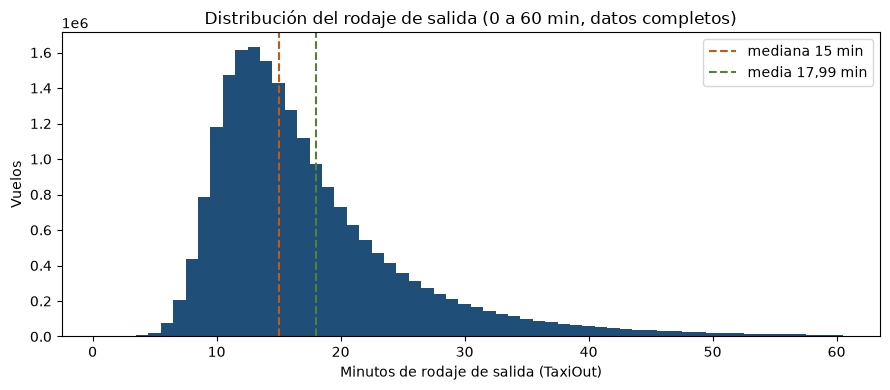

In [8]:
salida = con.execute("""
SELECT CAST(TaxiOut AS INTEGER) AS minuto, COUNT(*)::BIGINT AS vuelos
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiOut BETWEEN 0 AND 60
GROUP BY 1
ORDER BY 1
""").fetchdf()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(salida["minuto"], salida["vuelos"], width=1, color="#1f4e79")
ax.axvline(15, color="#c45911", linestyle="--", label="mediana 15 min")
ax.axvline(17.99, color="#548235", linestyle="--", label="media 17,99 min")
ax.set_xlabel("Minutos de rodaje de salida (TaxiOut)")
ax.set_ylabel("Vuelos")
ax.set_title("Distribución del rodaje de salida (0 a 60 min, datos completos)")
ax.legend()
fig.tight_layout()
plt.show()


**Lectura.** La salida típica está en **15 minutos** (mediana). La media es más alta, **17,99**, porque la cola derecha estira el promedio: el percentil 90 está en 28 min, el 95 en 35 y el 99 en 56. La desviación es 9,92 minutos.

La llegada es más corta: mediana **6**, media **8,35**, percentil 90 en 15. El combustible desperdiciado está sobre todo en la salida, no en el carreteo hasta el puesto.


## 5. Dónde y a qué hora se va el combustible

El top 10 usa solo la salida (`TaxiOut` no nulo y ≤ 180). Es el mismo filtro de la cifra de referencia. El CO2 está en toneladas del escenario bajo.


In [9]:
top = con.execute(f"""
SELECT
    Origin AS aeropuerto,
    COUNT(*)::BIGINT AS vuelos,
    ROUND(AVG(TaxiOut), 1) AS min_promedio,
    ROUND(SUM(TaxiOut) * {config.CONSUMO_KG_MIN_BAJO} * {config.FACTOR_CO2} / 1000) AS co2_t_bajo
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiOut <= {config.TAXI_MAX_MIN}
GROUP BY Origin
ORDER BY co2_t_bajo DESC
LIMIT 10
""").fetchdf()
top


,aeropuerto,vuelos,min_promedio,co2_t_bajo
0,ORD,853463,24.20,"392,002.00"
1,DFW,895874,19.70,"335,161.00"
2,DEN,905588,18.70,"321,352.00"
3,ATL,982159,16.50,"306,815.00"
4,CLT,600052,21.10,"239,863.00"
5,LGA,449442,24.20,"206,315.00"
6,SEA,488331,21.50,"198,740.00"
7,LAX,574470,18.00,"196,097.00"
8,LAS,558685,18.20,"192,275.00"
9,JFK,353717,27.00,"181,070.00"


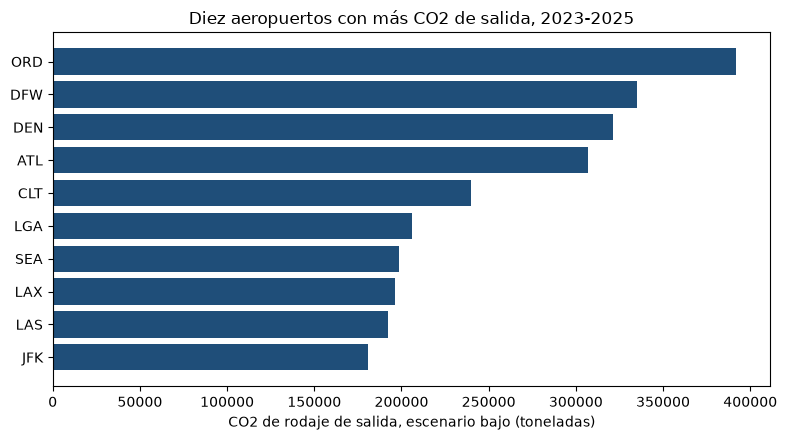

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ordenado = top.sort_values("co2_t_bajo")
ax.barh(ordenado["aeropuerto"], ordenado["co2_t_bajo"], color="#1f4e79")
ax.set_xlabel("CO2 de rodaje de salida, escenario bajo (toneladas)")
ax.set_title("Diez aeropuertos con más CO2 de salida, 2023-2025")
fig.tight_layout()
plt.show()


**Lectura.** ORD concentra unas **392.002 t**, seguido de DFW, DEN y ATL. No es solo "el que más vuela": JFK está en el puesto 10 de CO2 total, pero es el de rodaje más lento (27 min). ORD está alto en las dos listas (mucho volumen y 24,2 min de promedio).

Un plan de reducción tiene dos palancas distintas: bajar minutos en JFK, EWR, LGA y ORD, y vigilar el volumen de ORD, DFW, DEN y ATL aunque su promedio no sea el peor.


In [11]:
lentos = con.execute(f"""
SELECT Origin AS aeropuerto, COUNT(*)::BIGINT AS vuelos, ROUND(AVG(TaxiOut), 1) AS min_promedio
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiOut <= {config.TAXI_MAX_MIN}
GROUP BY Origin
HAVING COUNT(*) > {config.MIN_VUELOS_RANKING}
ORDER BY min_promedio DESC
LIMIT 8
""").fetchdf()
lentos


,aeropuerto,vuelos,min_promedio
0,JFK,353717,27.00
1,EWR,377726,24.60
2,ORD,853463,24.20
3,LGA,449442,24.20
4,SEA,488331,21.50
5,DCA,412705,21.30
6,CLT,600052,21.10
7,MIA,320051,21.00


**Lectura.** Entre los aeropuertos con más de 50.000 vuelos, el rodaje de salida más largo es JFK (27,0), EWR (24,6), LGA y ORD (24,2). SEA, DCA, CLT y MIA rondan los 21 minutos.


In [12]:
por_hora = con.execute(f"""
SELECT
    CASE
        WHEN CRSDepTime = 2400 THEN 0
        WHEN CRSDepTime BETWEEN 0 AND 2359 THEN CRSDepTime // 100
        ELSE NULL
    END AS hora,
    COUNT(*)::BIGINT AS vuelos,
    ROUND(AVG(TaxiOut), 2) AS min_promedio,
    ROUND(SUM(TaxiOut) * {config.CONSUMO_KG_MIN_BAJO} * {config.FACTOR_CO2} / 1e6, 1) AS miles_de_toneladas
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiOut <= {config.TAXI_MAX_MIN}
GROUP BY 1
HAVING hora IS NOT NULL
ORDER BY hora
""").fetchdf()
por_hora


,hora,vuelos,min_promedio,miles_de_toneladas
0,0,34006,15.32,9.90
1,1,11179,15.27,3.20
2,2,4501,14.26,1.20
3,3,2482,13.54,0.60
4,4,1241,12.66,0.30
5,5,586926,15.53,172.80
6,6,1450504,16.89,464.50
7,7,1449583,18.35,504.50
8,8,1408107,19.33,516.00
9,9,1162499,19.10,420.90


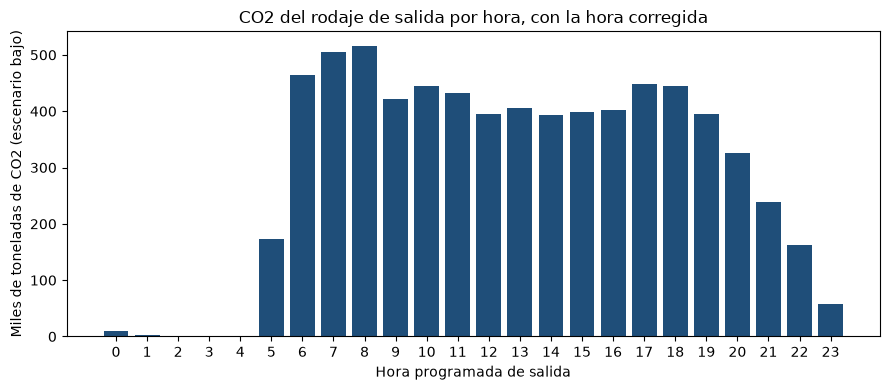

Hora con más CO2: 8
Hora con rodaje promedio más largo: 8


In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(por_hora["hora"], por_hora["miles_de_toneladas"], color="#1f4e79")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hora programada de salida")
ax.set_ylabel("Miles de toneladas de CO2 (escenario bajo)")
ax.set_title("CO2 del rodaje de salida por hora, con la hora corregida")
fig.tight_layout()
plt.show()
print("Hora con más CO2:", int(por_hora.loc[por_hora["miles_de_toneladas"].idxmax(), "hora"]))
print("Hora con rodaje promedio más largo:", int(por_hora.loc[por_hora["min_promedio"].idxmax(), "hora"]))


**Lectura.** Con la hora corregida, el CO2 de salida se concentra a las **8** (unas 516 mil toneladas), luego a las **7** (504 mil) y a las **6** (465 mil). La tarde vuelve a subir hacia las 17 y las 18, por debajo de la mañana.

El promedio más alto también está a las **8** (19,3 min), no a las 9. La frase "el promedio más alto es a las 9 (19,2 min)" salía del CAST que redondea. Al corregirlo, las 8 pasan a ser la hora más lenta y la de más CO2. Para operación, la mañana 6–8 es la franja donde una salida más fluida ahorra más combustible.


## 6. Día, mes y aerolínea

El día 1 de enero de 2023 fue domingo y en BTS `DayOfWeek` vale 7. Entonces 1 es lunes y 7 es domingo.


In [14]:
nombres_dia = {1: "lunes", 2: "martes", 3: "miércoles", 4: "jueves",
               5: "viernes", 6: "sábado", 7: "domingo"}
por_dia = con.execute(f"""
SELECT DayOfWeek AS dia, COUNT(*)::BIGINT AS vuelos, ROUND(AVG(TaxiOut), 2) AS min_promedio
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiOut <= {config.TAXI_MAX_MIN}
GROUP BY 1
ORDER BY 1
""").fetchdf()
por_dia["dia_nombre"] = por_dia["dia"].map(nombres_dia)
por_dia


,dia,vuelos,min_promedio,dia_nombre
0,1,3092899,17.91,lunes
1,2,2838060,17.71,martes
2,3,2869120,18.05,miércoles
3,4,3052916,18.33,jueves
4,5,3073505,18.27,viernes
5,6,2666986,17.59,sábado
6,7,3049850,18.02,domingo


In [15]:
por_mes = con.execute(f"""
SELECT Month AS mes, COUNT(*)::BIGINT AS vuelos, ROUND(AVG(TaxiOut), 2) AS min_promedio
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiOut <= {config.TAXI_MAX_MIN}
GROUP BY 1
ORDER BY 1
""").fetchdf()
por_mes


,mes,vuelos,min_promedio
0,1,1579166,18.73
1,2,1507644,18.13
2,3,1753698,17.85
3,4,1709193,17.55
4,5,1777551,17.70
5,6,1770302,17.97
6,7,1819601,18.15
7,8,1796121,17.88
8,9,1701030,17.81
9,10,1808753,17.71


In [16]:
por_aerolinea = con.execute(f"""
SELECT
    Reporting_Airline AS aerolinea,
    COUNT(*)::BIGINT AS vuelos,
    ROUND(AVG(TaxiOut), 2) AS min_promedio,
    ROUND(SUM(TaxiOut) * {config.CONSUMO_KG_MIN_BAJO} * {config.FACTOR_CO2} / 1000) AS co2_t_bajo
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiOut <= {config.TAXI_MAX_MIN}
GROUP BY 1
ORDER BY co2_t_bajo DESC
LIMIT 8
""").fetchdf()
por_aerolinea


,aerolinea,vuelos,min_promedio,co2_t_bajo
0,WN,4212100,13.78,"1,100,452.00"
1,AA,2855713,18.53,"1,003,081.00"
2,DL,2990341,17.36,"984,450.00"
3,UA,2258765,20.59,"881,593.00"
4,OO,2231681,20.46,"865,805.00"
5,YX,917781,21.48,"373,776.00"
6,AS,727214,20.46,"282,161.00"
7,OH,653231,22.17,"274,579.00"


**Lectura.** El día de la semana mueve poco el promedio: el jueves está en 18,33 min y el sábado en 17,59. No es la palanca principal.

El mes sí muestra una temporada: enero (18,73) y diciembre (18,52) son los más lentos; abril es el más corto (17,55). La diferencia cabe en poco más de un minuto. Sirve como contexto, no como la decisión.

En aerolíneas, Southwest (WN) aporta más CO2 de salida por cantidad de vuelos, aunque su promedio es el más corto del grupo (13,8 min). United (UA) y SkyWest (OO) rondan los 20,5 min. El CO2 total mezcla volumen y lentitud; hay que mirar las dos columnas, no solo el ranking de toneladas.


## 7. Variable objetivo y rodaje excesivo

La variable que se construye por vuelo, en el escenario bajo, es:

`co2_kg = (TaxiOut + TaxiIn) * 6 * 3,16`

cuando los dos tiempos existen y no pasan de 180 minutos.

"Rodaje excesivo" de salida: el vuelo supera el percentil 90 de **su propio aeropuerto**. Así un aeropuerto lento no marca como excesivos a casi todos sus vuelos, y uno rápido sí señala los días en que se sale de su costumbre.


In [17]:
exceso = con.execute(f"""
WITH limites AS (
    SELECT Origin, QUANTILE_CONT(TaxiOut, 0.9) AS p90
    FROM vuelos
    WHERE TaxiOut IS NOT NULL AND TaxiOut <= {config.TAXI_MAX_MIN}
    GROUP BY Origin
)
SELECT
    COUNT(*)::BIGINT AS vuelos_salida,
    SUM(v.TaxiOut > l.p90)::BIGINT AS rodaje_excesivo,
    ROUND(100.0 * SUM(v.TaxiOut > l.p90) / COUNT(*), 2) AS porcentaje
FROM vuelos v
JOIN limites l ON v.Origin = l.Origin
WHERE v.TaxiOut IS NOT NULL AND v.TaxiOut <= {config.TAXI_MAX_MIN}
""").fetchdf()
exceso


,vuelos_salida,rodaje_excesivo,porcentaje
0,20643336,1947883,9.44


**Lectura.** Quedan por encima del percentil 90 de su aeropuerto **1.947.883 vuelos**, el **9,44 %** de las salidas válidas. No es exactamente 10 % porque el corte es estricto (`>` y no `>=`) y porque muchos vuelos comparten el mismo minuto.

Si más adelante se entrena un modelo, esta es la etiqueta (sí/no). No hace falta para responder la pregunta de Sostenibilidad: los rankings de aeropuerto y de hora ya salen de la suma.

**Candidatas a variables, si el modelo se hace:** aeropuerto de origen, hora programada corregida, día de la semana, mes, aerolínea y el clima del día (lluvia, nieve, viento). No se usarían las columnas de causa del atraso (`CarrierDelay`, `WeatherDelay`, etc.): solo se conocen después del vuelo.

El entrenamiento, si se hace, sería sobre una muestra. Este cuaderno y el pipeline de CO2 no muestrean.


## 8. Qué información falta, y el clima que sí tenemos

No está en BTS el tipo de avión ni el motor. Sin eso, 6 kg/min es un supuesto de un A320 en rodaje, no una medición de cada vuelo. Tampoco hay congestión de pista ni ocupación de puertas. El Dorado y el resto de Colombia no están en este dataset.

Sí hay clima diario de Open-Meteo para **20 aeropuertos de origen**, 2023-2025. La primera tabla pone una sola etiqueta por vuelo (si nieva y llueve, cuenta como nieve). La segunda mira cada fenómeno por separado, porque si no el viento queda escondido dentro de los días de lluvia.


In [18]:
ruta_clima = str(config.RUTA_CLIMA).replace("\\", "/")
prioridad = con.execute(f"""
WITH base AS (
    SELECT v.TaxiOut,
        CASE
            WHEN c.nieve_cm > 0 THEN 'nieve'
            WHEN c.precipitacion_mm > {config.LLUVIA_FUERTE_MM} THEN 'lluvia_fuerte'
            WHEN c.viento_max_kmh >= {config.VIENTO_FUERTE_KMH} THEN 'viento_fuerte'
            WHEN c.precipitacion_mm > 0 THEN 'lluvia_leve'
            ELSE 'normal'
        END AS condicion
    FROM vuelos v
    INNER JOIN read_csv_auto('{ruta_clima}') c
        ON v.Origin = c.Origin
       AND CAST(v.FlightDate AS DATE) = CAST(c.Fecha AS DATE)
    WHERE v.TaxiOut IS NOT NULL AND v.TaxiOut <= {config.TAXI_MAX_MIN}
)
SELECT condicion, COUNT(*)::BIGINT AS vuelos, ROUND(AVG(TaxiOut), 2) AS min_promedio_salida
FROM base
GROUP BY 1
ORDER BY min_promedio_salida DESC
""").fetchdf()
print("Una etiqueta por vuelo:")
display(prioridad)

independiente = con.execute(f"""
WITH j AS (
    SELECT v.TaxiOut, c.precipitacion_mm AS p, c.nieve_cm AS nieve, c.viento_max_kmh AS viento
    FROM vuelos v
    INNER JOIN read_csv_auto('{ruta_clima}') c
        ON v.Origin = c.Origin
       AND CAST(v.FlightDate AS DATE) = CAST(c.Fecha AS DATE)
    WHERE v.TaxiOut IS NOT NULL AND v.TaxiOut <= {config.TAXI_MAX_MIN}
)
SELECT 'lluvia_fuerte' AS condicion, COUNT(*)::BIGINT AS vuelos, ROUND(AVG(TaxiOut), 2) AS min_promedio
FROM j WHERE p > {config.LLUVIA_FUERTE_MM}
UNION ALL
SELECT 'sin_lluvia', COUNT(*)::BIGINT, ROUND(AVG(TaxiOut), 2) FROM j WHERE p = 0 AND nieve = 0
UNION ALL
SELECT 'nieve', COUNT(*)::BIGINT, ROUND(AVG(TaxiOut), 2) FROM j WHERE nieve > 0
UNION ALL
SELECT 'sin_nieve', COUNT(*)::BIGINT, ROUND(AVG(TaxiOut), 2) FROM j WHERE nieve = 0
UNION ALL
SELECT 'viento_fuerte', COUNT(*)::BIGINT, ROUND(AVG(TaxiOut), 2) FROM j WHERE viento >= {config.VIENTO_FUERTE_KMH}
UNION ALL
SELECT 'viento_normal', COUNT(*)::BIGINT, ROUND(AVG(TaxiOut), 2) FROM j WHERE viento < {config.VIENTO_FUERTE_KMH}
""").fetchdf()
print("Cada fenómeno por separado:")
display(independiente)


Una etiqueta por vuelo:


,condicion,vuelos,min_promedio_salida
0,nieve,438987,26.40
1,lluvia_fuerte,1468265,22.10
2,viento_fuerte,33723,20.45
3,lluvia_leve,2737294,20.17
4,normal,5891944,18.88


Cada fenómeno por separado:


,condicion,vuelos,min_promedio
0,lluvia_fuerte,1579546,22.66
1,sin_lluvia,5911354,18.88
2,nieve,438987,26.40
3,sin_nieve,10131226,19.70
4,viento_fuerte,67938,22.27
5,viento_normal,10502275,19.96


**Lectura.** En los 20 aeropuertos con clima, un día de nieve promedia **26,4 min** de rodaje de salida, frente a **19,7** sin nieve: unos 6,7 minutos más, cerca de **34 %**.

La lluvia fuerte (más de 5 mm) promedia **22,7 min**, frente a **18,9** en un día seco y sin nieve: unos 3,8 minutos más, cerca de **20 %**.

El viento de 40 km/h o más promedia **22,3 min**, frente a **20,0**: unos 2,3 minutos más, cerca de **12 %**. En la tabla de una sola etiqueta el viento parece más débil, porque muchos de esos días ya quedaron clasificados como lluvia o nieve. Por eso se muestran las dos tablas.

Esto no demuestra que el clima sea la causa: un día de nieve también tiene menos ritmo en pista y más esperas. El dato alcanza para decir que el rodaje se alarga en esos días y que un reporte de Sostenibilidad no debería tratar todos los días como iguales. El clima es diario, no de la hora del vuelo, y no cubre los 300 aeropuertos.


## 9. Total por año y qué se puede evitar

Horas y CO2 con la regla global (ambos tiempos presentes y ≤ 180). El escenario alto es el doble y sigue **por validar**.


In [19]:
resumen = con.execute(f"""
SELECT
    Year AS anio,
    COUNT(*)::BIGINT AS vuelos,
    ROUND((SUM(TaxiOut) + SUM(TaxiIn)) / 60, 0) AS horas,
    ROUND((SUM(TaxiOut) + SUM(TaxiIn)) * {config.CONSUMO_KG_MIN_BAJO} * {config.FACTOR_CO2} / 1000) AS co2_t_bajo,
    ROUND((SUM(TaxiOut) + SUM(TaxiIn)) * {config.CONSUMO_KG_MIN_ALTO} * {config.FACTOR_CO2} / 1000) AS co2_t_alto
FROM vuelos
WHERE TaxiOut IS NOT NULL AND TaxiIn IS NOT NULL
  AND TaxiOut <= {config.TAXI_MAX_MIN} AND TaxiIn <= {config.TAXI_MAX_MIN}
GROUP BY Year
ORDER BY Year
""").fetchdf()
resumen


,anio,vuelos,horas,co2_t_bajo,co2_t_alto
0,2023,6758238,"2,873,412.00","3,268,794.00","6,537,587.00"
1,2024,6981102,"3,051,436.00","3,471,314.00","6,942,628.00"
2,2025,6896882,"3,132,488.00","3,563,518.00","7,127,036.00"


**Lectura.** Las horas de rodaje pasan de 2.873.412 en 2023 a 3.132.488 en 2025: **+9,0 %**. Los vuelos válidos solo crecen cerca de un 2 % (de 6.758.238 a 6.896.882). El aumento del CO2 no es solo "hay más vuelos": cada vuelo pasa más tiempo en tierra.

En tres años, el escenario bajo suma **10,3 millones de toneladas** de CO2. Bajar el rodaje un 10 % evitaría cerca de **1,03 millones de toneladas**, porque el factor es lineal. Llevar la salida de los aeropuertos grandes y lentos hasta la mediana de ese grupo (15,7 min) evita una cifra parecida, alrededor de **1,01 millones de toneladas**, y esa segunda cuenta es solo de salida.

Límites que hay que decir en voz alta: no conocemos el motor de cada vuelo; 12 kg/min está por validar; el empuje real en rodaje no es siempre el 7 % que supone OACI (anda entre 3 % y 10 %); y estos números son de Estados Unidos, no de El Dorado.
